In [1]:
# 1. imports & config
import os
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torch.optim as optim

import albumentations as A
from albumentations.pytorch import ToTensorV2

# ---- paths & training params ----
DATA_ROOT = "/workspace/ML Main Large/Processed data"   # change if needed
TRAIN_SPLIT_DIR = os.path.join(DATA_ROOT, "train")  # we will split this into train/val

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_SIZE = 256
BATCH_SIZE = 4          # reduce to 2 or 1 if OOM
NUM_WORKERS = 2         # set 0 if you get dataloader issues
EPOCHS = 20
LR = 1e-4
VAL_RATIO = 0.1         # 10% of train for validation
MODEL_SAVE_PATH = "unet_full_best.pth"
SEED = 42

print("Device:", DEVICE)

# reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

Device: cuda


In [2]:
# 2: dataset class (uses only processed/train)

class RoadTrainDataset(Dataset):
    """
    Loads image-mask pairs from:
    processed/train/images
    processed/train/masks
    """
    def __init__(self, root, transforms=None):
        img_dir = os.path.join(root, "images")
        mask_dir = os.path.join(root, "masks")

        if not os.path.exists(img_dir):
            raise FileNotFoundError(f"Image folder not found: {img_dir}")
        if not os.path.exists(mask_dir):
            raise FileNotFoundError(f"Mask folder not found: {mask_dir}")

        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transforms = transforms

        self.img_names = sorted(os.listdir(self.img_dir))

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)

        # guess mask name: 100034_sat.jpg -> 100034_mask.png
        base = img_name.split("_sat")[0]
        mask_name = f"{base}_mask.png"
        mask_path = os.path.join(self.mask_dir, mask_name)

        img = cv2.imread(img_path)
        if img is None:
            raise RuntimeError(f"Failed to read image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise RuntimeError(f"Failed to read mask: {mask_path}")

        # binarize mask (0 / 1)
        mask = (mask > 127).astype("float32")

        if self.transforms:
            augmented = self.transforms(image=img, mask=mask)
            img = augmented["image"]      # (C,H,W) float
            mask = augmented["mask"]      # (H,W) or (1,H,W)
        else:
            img = ToTensorV2()(image=img)["image"]
            mask = torch.from_numpy(mask).float()

        # ensure mask shape (1,H,W)
        if isinstance(mask, torch.Tensor):
            if mask.dim() == 2:
                mask = mask.unsqueeze(0)
        else:
            mask = torch.from_numpy(mask).unsqueeze(0).float()

        return img.float(), mask.float()

# quick sanity check
full_ds = RoadTrainDataset(TRAIN_SPLIT_DIR)
print("Total pairs in processed/train:", len(full_ds))

Total pairs in processed/train: 14688


In [3]:
#3: transforms & dataloaders

train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.2),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# re-create dataset with transforms
full_ds = RoadTrainDataset(TRAIN_SPLIT_DIR, transforms=train_transform)

# split into train/val
val_len = int(len(full_ds) * VAL_RATIO)
train_len = len(full_ds) - val_len
train_ds, val_ds = random_split(full_ds, [train_len, val_len])

# IMPORTANT: validation must not use augmentations like flip/rotate
# So we override val_ds.dataset.transforms to val_transform
val_ds.dataset.transforms = val_transform

print(f"Train samples: {len(train_ds)}, Val samples: {len(val_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# check one batch
imgs, masks = next(iter(train_loader))
print("Batch shapes - imgs:", imgs.shape, "masks:", masks.shape)

Train samples: 13220, Val samples: 1468
Batch shapes - imgs: torch.Size([4, 3, 256, 256]) masks: torch.Size([4, 1, 256, 256])


In [4]:
# 4: UNet Full model 

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class UNetFull(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)
        e2 = self.enc2(p1)
        p2 = self.pool2(e2)
        e3 = self.enc3(p2)
        p3 = self.pool3(e3)
        e4 = self.enc4(p3)
        p4 = self.pool4(e4)

        b = self.bottleneck(p4)

        u4 = self.up4(b)
        d4 = self.dec4(torch.cat([u4, e4], dim=1))
        u3 = self.up3(d4)
        d3 = self.dec3(torch.cat([u3, e3], dim=1))
        u2 = self.up2(d3)
        d2 = self.dec2(torch.cat([u2, e2], dim=1))
        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, e1], dim=1))

        out = self.final(d1)   # logits
        return out

model = UNetFull().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
print("UNetFull params (M):", n_params)

UNetFull params (M): 31.037633


In [5]:
# 5: loss, metrics, optimizer, scaler

bce_loss = nn.BCEWithLogitsLoss()

def dice_loss_logits(pred, target, eps=1e-6):
    prob = torch.sigmoid(pred)
    prob_flat = prob.view(prob.size(0), -1)
    target_flat = target.view(target.size(0), -1)
    inter = (prob_flat * target_flat).sum(dim=1)
    denom = prob_flat.sum(dim=1) + target_flat.sum(dim=1)
    dice = (2 * inter + eps) / (denom + eps)
    return 1.0 - dice.mean()

def total_loss(pred, mask):
    return bce_loss(pred, mask) + dice_loss_logits(pred, mask)

def iou_score(pred, target, thr=0.5, eps=1e-6):
    prob = torch.sigmoid(pred)
    pred_bin = (prob > thr).float()
    inter = (pred_bin * target).sum(dim=(1,2,3))
    union = pred_bin.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - inter
    return ((inter + eps) / (union + eps)).mean().item()

optimizer = optim.AdamW(model.parameters(), lr=LR)
scaler = torch.amp.GradScaler(device="cuda" if DEVICE=="cuda" else "cpu")

In [6]:
# 6: train & validate functions

def train_one_epoch(model, loader, optimizer, scaler, epoch):
    model.train()
    running_loss = 0.0
    running_iou = 0.0
    pbar = tqdm(enumerate(loader), total=len(loader), desc=f"Train E{epoch}")
    optimizer.zero_grad()

    for step, (imgs, masks) in pbar:
        imgs = imgs.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        if masks.dim() == 3:
            masks = masks.unsqueeze(1)

        with torch.amp.autocast(device_type="cuda" if DEVICE=="cuda" else "cpu"):
            preds = model(imgs)
            loss = total_loss(preds, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        running_loss += loss.item()
        with torch.no_grad():
            running_iou += iou_score(preds, masks)

        avg_loss = running_loss / (step+1)
        avg_iou = running_iou / (step+1)
        pbar.set_postfix(loss=f"{avg_loss:.4f}", iou=f"{avg_iou:.4f}")

    return running_loss / len(loader), running_iou / len(loader)

def validate_epoch(model, loader):
    model.eval()
    running_loss = 0.0
    running_iou = 0.0
    with torch.no_grad():
        for imgs, masks in tqdm(loader, total=len(loader), desc="Val"):
            imgs = imgs.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)
            if masks.dim() == 3:
                masks = masks.unsqueeze(1)

            with torch.amp.autocast(device_type="cuda" if DEVICE=="cuda" else "cpu"):
                preds = model(imgs)
                loss = total_loss(preds, masks)

            running_loss += loss.item()
            running_iou += iou_score(preds, masks)

    return running_loss / len(loader), running_iou / len(loader)

In [7]:
# 7: training loop

best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    train_loss, train_iou = train_one_epoch(model, train_loader, optimizer, scaler, epoch)
    val_loss, val_iou = validate_epoch(model, val_loader)

    print(f"Train loss: {train_loss:.4f} | Train IoU: {train_iou:.4f}")
    print(f"Val   loss: {val_loss:.4f} | Val   IoU: {val_iou:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print("✅ Saved best model to", MODEL_SAVE_PATH)

    if DEVICE == "cuda":
        torch.cuda.empty_cache()

print("Training complete. Best val loss:", best_val_loss)


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:744: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:919.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


al: 100%|██████████| 367/367 [00:02<00:00, 159.61it/s]it/s, iou=0.3812, loss=0.7529]

Train loss: 0.7529 | Train IoU: 0.3812
Val   loss: 0.5914 | Val   IoU: 0.4156
✅ Saved best model to unet_full_best.pth

Epoch 2/20




al: 100%|██████████| 367/367 [00:02<00:00, 161.49it/s]it/s, iou=0.4477, loss=0.5376]

Train loss: 0.5376 | Train IoU: 0.4477
Val   loss: 0.5274 | Val   IoU: 0.4686
✅ Saved best model to unet_full_best.pth

Epoch 3/20


...

Train loss: 0.4268 | Train IoU: 0.5521
Val   loss: 0.4612 | Val   IoU: 0.5338
✅ Saved best model to unet_full_best.pth

Epoch 19/20




al: 100%|██████████| 367/367 [00:02<00:00, 161.56it/s]2it/s, iou=0.5532, loss=0.4245]

Train loss: 0.4245 | Train IoU: 0.5532
Val   loss: 0.4601 | Val   IoU: 0.5303
✅ Saved best model to unet_full_best.pth

Epoch 20/20



Val: 100%|██████████| 367/367 [00:02<00:00, 161.87it/s]2it/s, iou=0.5587, loss=0.4205]

Train loss: 0.4205 | Train IoU: 0.5587
Val   loss: 0.4635 | Val   IoU: 0.5420
Training complete. Best val loss: 0.4601133863266547


In [13]:
total_loss_fn = total_loss

In [14]:
def evaluate_saved_model(model_path, val_dataset, batch_size=4):
    """
    Load a trained UNetFull model and evaluate on the new validation set.
    Computes:
      - Average Loss
      - Average IoU
    Also shows 3 prediction samples
    """
    print("\nLoading saved model for evaluation:", model_path)

    # 1. Load model
    model = UNetFull().to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    # 2. Validation loader
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    total_loss = 0.0
    total_iou = 0.0

    print("\nRunning evaluation on validation set...")
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader):
            imgs = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            if masks.dim() == 3:
                masks = masks.unsqueeze(1)

            with torch.amp.autocast(device_type="cuda" if DEVICE=="cuda" else "cpu"):
                preds = model(imgs)
                loss = total_loss_fn(preds, masks)

            total_loss += loss.item()
            total_iou  += iou_score(preds, masks)

    avg_loss = total_loss / len(val_loader)
    avg_iou  = total_iou / len(val_loader)

    print("\n VALIDATION METRICS")
    print(f"Validation Loss : {avg_loss:.4f}")
    print(f"Validation IoU  : {avg_iou:.4f}")

    # ---- Visualization Section ----
    print("\nShowing predictions on validation samples...")
    plt.figure(figsize=(12, 10))

    for i in range(3):
        img, mask = val_dataset[i]
        inp = img.unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            pred = model(inp)
            pred_mask = (torch.sigmoid(pred) > 0.5).float().cpu().squeeze().numpy()

        img_np  = (img.permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
        mask_np = mask.squeeze().cpu().numpy()

        plt.subplot(3, 3, i*3 + 1)
        plt.imshow(img_np); plt.title("Image"); plt.axis("off")

        plt.subplot(3, 3, i*3 + 2)
        plt.imshow(mask_np, cmap="gray"); plt.title("GT Mask"); plt.axis("off")

        plt.subplot(3, 3, i*3 + 3)
        plt.imshow(img_np)
        plt.imshow(pred_mask, cmap="Reds", alpha=0.4)
        plt.title("Pred Overlay"); plt.axis("off")

    plt.tight_layout()
    plt.show()


Loading saved model for evaluation: unet_full_best.pth

Running evaluation on validation set...



00%|██████████| 367/367 [00:02<00:00, 156.62it/s]


 VALIDATION METRICS
Validation Loss : 0.4601
Validation IoU  : 0.5303

Showing predictions on validation samples...


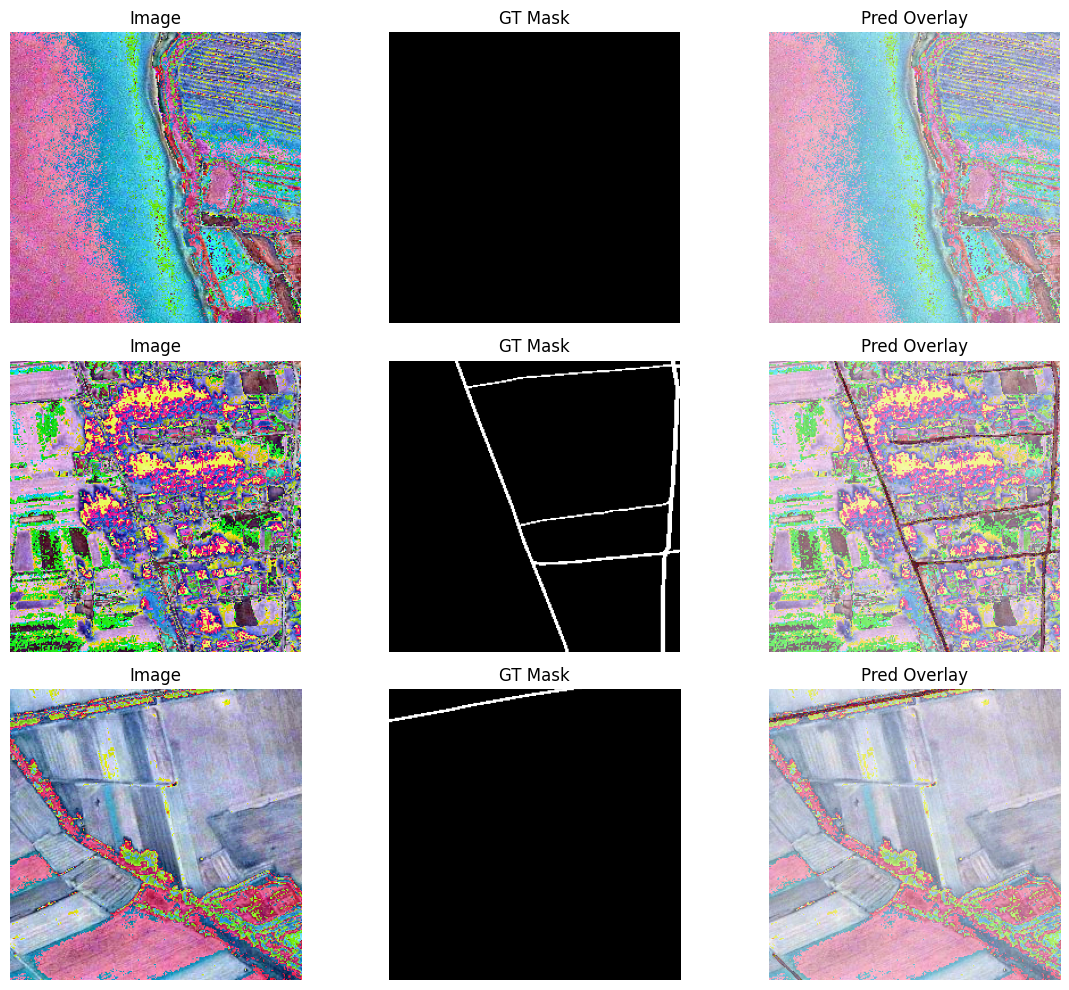

In [15]:
evaluate_saved_model("unet_full_best.pth", val_ds)

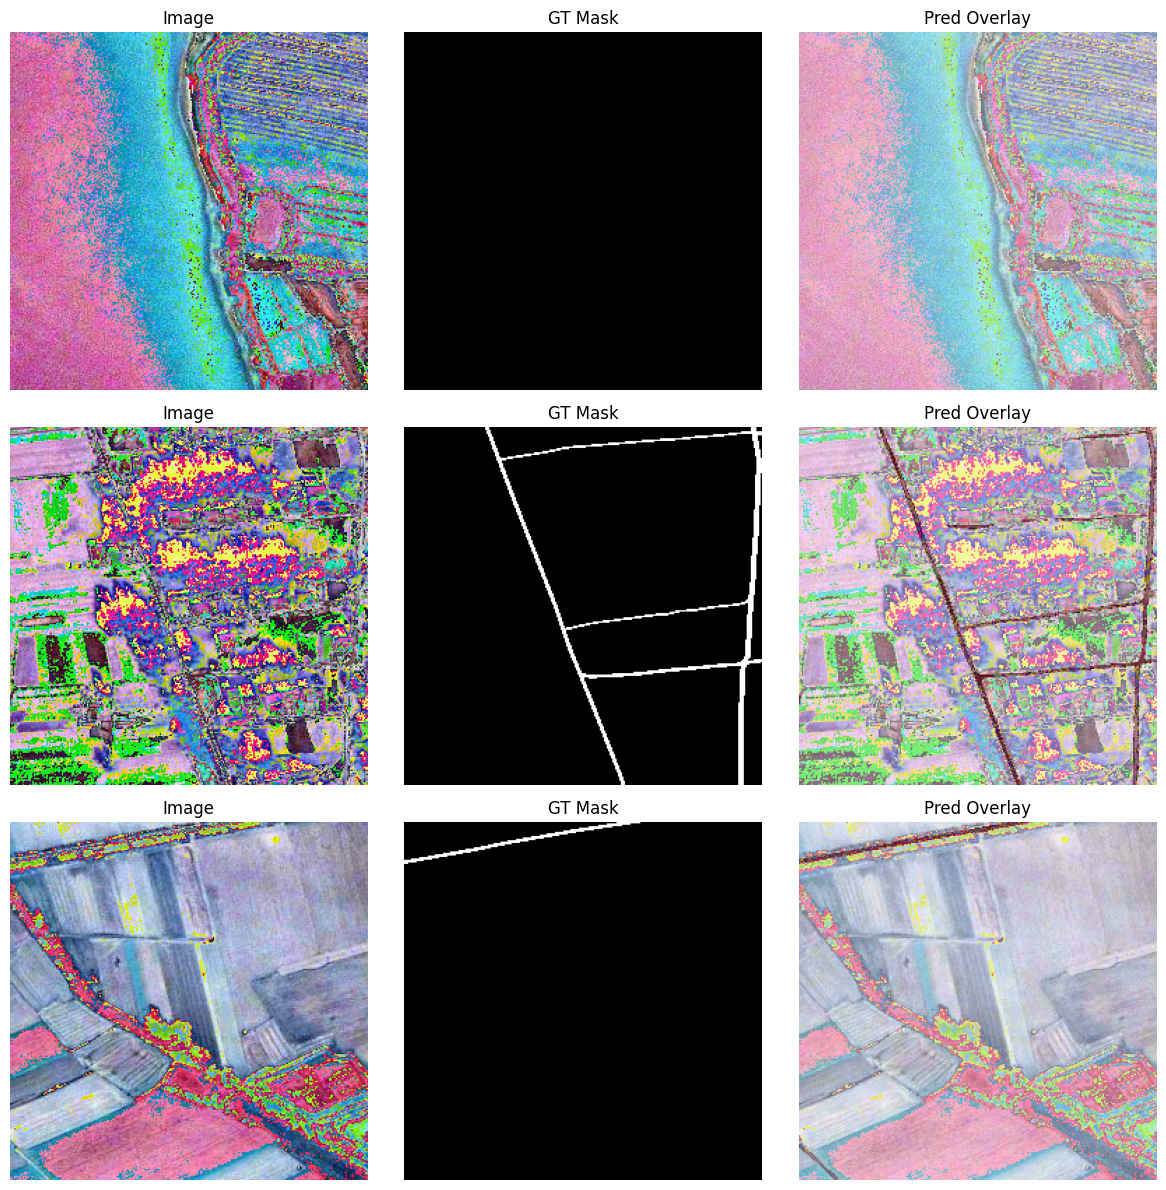

In [9]:
# 8: visualization on a few test samples

def visualize_samples(model, dataset, n=3):
    model.eval()
    plt.figure(figsize=(12, 4*n))
    with torch.no_grad():
        for i in range(n):
            img, mask = dataset[i]
            inp = img.unsqueeze(0).to(DEVICE)
            with torch.amp.autocast(device_type="cuda" if DEVICE=="cuda" else "cpu"):
                pred = model(inp)
            pred_mask = (torch.sigmoid(pred) > 0.5).float().cpu().squeeze().numpy()
            img_np = (img.permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
            gt_np = mask.squeeze().cpu().numpy()

            plt.subplot(n, 3, i*3 + 1)
            plt.imshow(img_np); plt.title("Image"); plt.axis("off")

            plt.subplot(n, 3, i*3 + 2)
            plt.imshow(gt_np, cmap="gray"); plt.title("GT Mask"); plt.axis("off")

            plt.subplot(n, 3, i*3 + 3)
            plt.imshow(img_np)
            plt.imshow(pred_mask, cmap="Reds", alpha=0.4)
            plt.title("Pred Overlay"); plt.axis("off")

    plt.tight_layout()
    plt.show()

# use the *validation* dataset for visualization
visualize_samples(model, val_ds, n=3)